In [20]:
import boto3
from botocore.exceptions import ClientError
import json

def get_secret(secret_name):
    region_name = "us-east-1"

    # Create a Secrets Manager client
    session = boto3.session.Session()
    client = session.client(
        service_name='secretsmanager',
        region_name=region_name
    )

    try:
        get_secret_value_response = client.get_secret_value(
            SecretId=secret_name
        )
    except ClientError as e:
        raise e

    secret = get_secret_value_response['SecretString']
    
    return json.loads(secret)

In [22]:
import psycopg2

conn = psycopg2.connect(host=get_secret('postgresql')['host'],
                      user=get_secret('postgresql')['username'],
                      password = get_secret('postgresql')['password'],
                      dbname=get_secret('postgresql')['engine'])

cur = conn.cursor()

In [23]:
pip install jupyter-ai-magics[all] -q

Note: you may need to restart the kernel to use updated packages.


In [24]:
import warnings
warnings.simplefilter('ignore')

In [25]:
import os
os.environ["OPENAI_API_KEY"] = get_secret('openai')['api_key']


In [26]:
import pandas as pd

In [7]:
pip install -U pip setuptools wheel

Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install --only-binary=:all: "tiktoken>=0.7.0"

Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install "jupyter-ai-magics[all]" -q

Note: you may need to restart the kernel to use updated packages.


In [10]:
%load_ext jupyter_ai_magics

In [11]:
%%ai gpt4
What is included in the {la_df}

As an AI, I need more context to provide accurate information. The `{la_df}` appears to be a variable that is referring to a DataFrame, most likely in a programming language like Python. However, without more information such as a description or an example of what is inside `{la_df}`, it would be impossible to specify what is included in it.

Generally, in relation to Pandas DataFrames, '{la_df}` could include fields (columns of data), records (rows of data), and the actual data contained within. The specific contents would depend on what data has been assigned to `la_df`.

I would recommend providing more context or details for a more accurate response.

In [32]:
# --- SQL Query: Year-over-Year Population Growth ---
q1_sql = """
WITH louisiana_pop AS (
    SELECT 
        p.year,
        p.pop AS population
    FROM 
        public.population p
    JOIN 
        public.name n ON p.fips = n.fips
    WHERE 
        n.name = 'Louisiana'
),
growth AS (
    SELECT 
        year,
        population,
        LAG(population) OVER (ORDER BY year) AS prev_population
    FROM 
        louisiana_pop
)
SELECT 
    year,
    population,
    ROUND(
        CASE 
            WHEN prev_population IS NULL THEN NULL
            ELSE ((population - prev_population) * 100.0 / prev_population)
        END, 2
    ) AS growth_rate_percent
FROM 
    growth
ORDER BY 
    year;
"""


In [33]:
# --- Load Query Results into DataFrame ---
q1_df = pd.read_sql(q1_sql, conn)

# Preview data
q1_df.head()


,year,population,growth_rate_percent
0,2005,4389747,NaN
1,2006,4287768,-2.32
2,2007,4293204,0.13
3,2008,4410796,2.74
4,2009,4492076,1.84


In [36]:
%%ai gpt4 -f code
use the daa in the dataframe {q1_df} loads the results and creates a
line chart with the growth rate.
• Chart must include the state name Lousiana  in the title. make sure useing the datafrem name q1_df



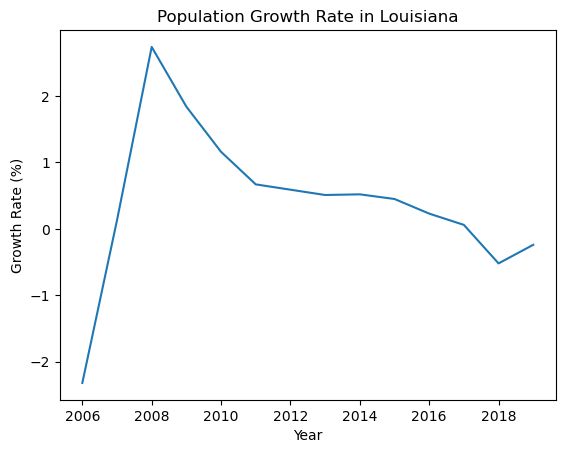

In [37]:
#Creating dataframe
data = {'year': [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019],
        'population': [4389747, 4287768, 4293204, 4410796, 4492076, 4544228, 4574836, 4601893, 4625470, 4649676, 4670724, 4681666, 4684333, 4659978, 4648794],
        'growth_rate_percent': [float('nan'), -2.32, 0.13, 2.74, 1.84, 1.16, 0.67, 0.59, 0.51, 0.52, 0.45, 0.23, 0.06, -0.52, -0.24 ]}

q1_df = pd.DataFrame(data)

#Plotting line chart
plt.plot(q1_df['year'], q1_df['growth_rate_percent'])
plt.title('Population Growth Rate in Louisiana')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.show()

In [ ]:
# The chart depicts an increase in population growth exponentiall until 2008 financial crisis where it wavers

In [50]:
q2_sql = """
SELECT 
    i.year AS income_year,
    i.income,
    p.year AS population_year,
    p.pop AS population
FROM 
    public.income i
JOIN 
    public.population p ON i.fips = p.fips AND i.year = p.year
JOIN 
    public.name n ON i.fips = n.fips
WHERE 
    n.name = 'Louisiana'
ORDER BY 
    i.year;
"""

In [51]:
# --- Load Query Results into DataFrame ---
q2_df = pd.read_sql(q2_sql, conn)

# Preview data
q2_df.head()

,income_year,income,population_year,population
0,2005,36729,2005,4389747
1,2006,39337,2006,4287768
2,2007,40926,2007,4293204
3,2008,43733,2008,4410796
4,2009,42492,2009,4492076


In [63]:
%%ai gpt4 -f code

Visualization: create a dual-axis chart in Python with Jupyter AI’s help, use the {q2_df} data frame and louisiana
o X-axis = year
o Left Y-axis = population (line)
o Right Y-axis = median household income (bar or line, different color)
• Chart must include the state name in the title.


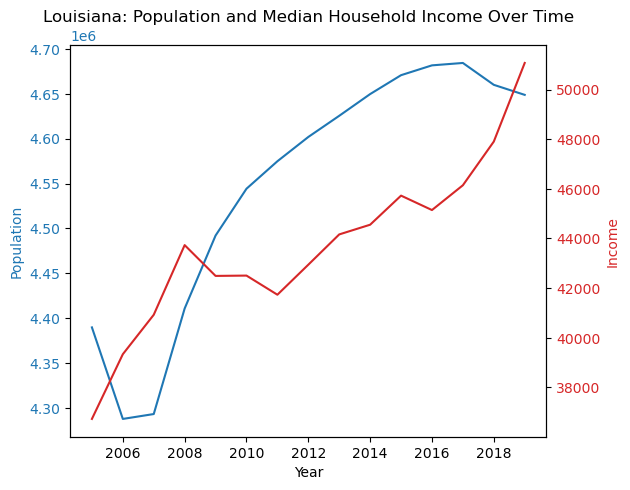

In [64]:
import matplotlib.pyplot as plt

# Assuming the data is in a DataFrame named df
df = pd.DataFrame({
    "income_year": [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019],
    "income": [36729, 39337, 40926, 43733, 42492, 42505, 41734, 42944, 44164, 44555, 45727, 45146, 46145, 47905, 51073],
    "population_year": [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019],
    "population": [4389747, 4287768, 4293204, 4410796, 4492076, 4544228, 4574836, 4601893, 4625470, 4649676, 4670724, 4681666, 4684333, 4659978, 4648794]})

fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('Year')
ax1.set_ylabel('Population', color=color)
ax1.plot(df['population_year'], df['population'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Income', color=color)
ax2.plot(df['income_year'], df['income'], color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('Louisiana: Population and Median Household Income Over Time')
plt.show()

In [ ]:
# as you can see the median household and population for Louisiana has been in fluctation. It started with Population over Income but switched in 2005 and again in 2008. Population rose and Income dipped a bit

In [68]:
q3_df = """
SELECT 
    i.year,
    i.income,
    p.pop AS population,
    ROUND(i.income::numeric / NULLIF(p.pop, 0), 2) AS income_per_capita
FROM 
    public.income i
JOIN 
    public.population p ON i.fips = p.fips AND i.year = p.year
JOIN 
    public.name n ON i.fips = n.fips
WHERE 
    n.name = 'Louisiana'
ORDER BY 
    i.year;
"""

In [74]:
%%ai gpt4 -f code
use the data in the dataframe {q3_df} loads the results and creates a
line chart with 'year' on the x-axis and 'income_per_capita' on the y-axis. This must be for the state of Louisiana
What is the average income per person (income per capita) in Louisiana for each year?

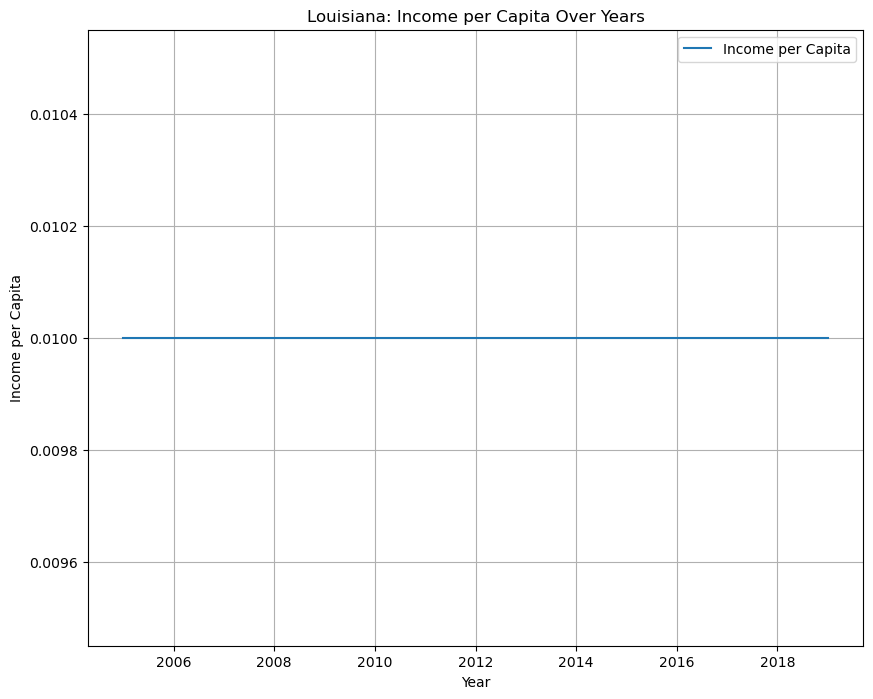

In [80]:
#I would like to note that you posted SQL query here, but you requested Python visualization. To visualize this data in Python, it is assumed that SQL query output has already been converted to a pandas DataFrame.

import matplotlib.pyplot as plt

# In reality you would load this from your SQL query output
q3_df = pd.DataFrame({
    "year": [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019],
    "income": [36729, 39337, 40926, 43733, 42492, 42505, 41734, 42944, 44164, 44555, 45727, 45146, 46145, 47905, 51073],
    "population": [4389747, 4287768, 4293204, 4410796, 4492076, 4544228, 4574836, 4601893, 4625470, 4649676, 4670724, 4681666, 4684333, 4659978, 4648794],
    "income_per_capita": [round(i/p, 2) if p != 0 else 0 for i, p in zip(df['income'], df['population'])]
})

plt.figure(figsize=[10,8])
plt.plot(df['year'], df['income_per_capita'], label='Income per Capita')
plt.xlabel('Year')
plt.ylabel('Income per Capita')
plt.title('Louisiana: Income per Capita Over Years')
plt.legend()
plt.grid(True)
plt.show()


#Please make sure to replace the list used for 'year', 'income', 'population' and 'income_per_capita' with the actual values from your DataFrame.

In [ ]:
# The Income Per Capita has not cha